In [11]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
%matplotlib inline

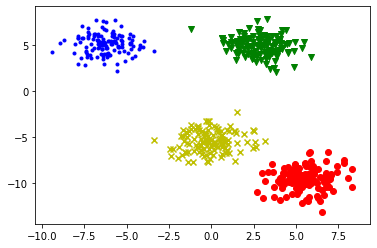

In [12]:
x,y = make_blobs(n_samples=500, centers=4, n_features=2,cluster_std = 1.2,random_state = 10)
markers = ['o','v','x','.']
colors = ['r','g','y','b']
for i,label in enumerate(y):
    plt.scatter(x[i,0],x[i,1],marker=markers[label],color =colors[label])

In [13]:
y[y == 3] = 0
y[y == 2] = 1

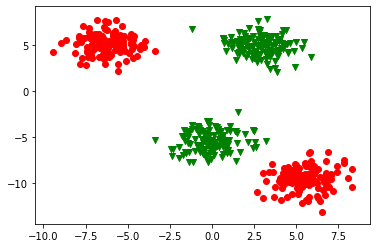

In [14]:
for i,label in enumerate(y):
    plt.scatter(x[i,0],x[i,1],marker=markers[label],color = colors[label])

In [15]:
from torch import nn

class net(nn.Module):
    def __init__(self,sig = True):
        super(net,self).__init__()
        self.fc1 = nn.Linear(2,10)
        self.sig = sig
        if self.sig:
            self.act = nn.Sigmoid()
        self.fc2 = nn.Linear(10,2)
    def forward(self,x):
        if self.sig:
            return self.fc2(self.act(self.fc1(x)))
        else:
            return self.fc2(self.fc1(x))

In [16]:
import torch
data = torch.from_numpy(x).float()

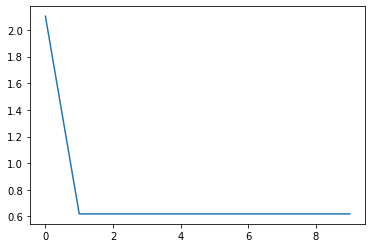

In [17]:
model = net(sig=False)
losses = []
criteron = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr = 0.1)
y = torch.from_numpy(y).long()
for i in range(1000):
    out = model(data)
    optimizer.zero_grad()
#     print(out.shape,y.shape)
    loss = criteron(out,y)
    loss.backward()
    optimizer.step()
    if i % 100 == 0:
#         print(loss.item())
        losses.append(loss.item())
label = torch.argmax(out,dim = 1)
plt.plot(losses)

In [18]:
# for i,l in enumerate(label.data.numpy()):
#     plt.scatter(x[i,0],x[i,1],marker=markers[l],color = 'b')

In [19]:
import numpy as np 
data = np.zeros((10000,2))
cnt = 0
scale = 1
for i,m in enumerate(np.linspace(-15*scale,10*scale,100)):
    for j,n in enumerate(np.linspace(-10*scale,10*scale,100)):
        data[cnt,:] = [n,m]
        cnt += 1
# plt.scatter(data[:,0],data[:,1])

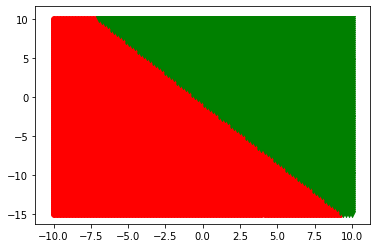

In [20]:
data = torch.from_numpy(data).float()
out = model(data)
label = torch.argmax(out,dim = 1)
for i,l in enumerate(label.data.numpy()):
    plt.scatter(data[i,0],data[i,1],marker=markers[l],color = colors[l])